# Partie III — Modèles de Séquence : RNN, LSTM, GRU & Seq2Seq

**Deep Learning — Projet de Fin de Module**

Ce notebook couvre :
- Modèles de langage probabilistes et perplexité
- Implémentation et comparaison RNN / LSTM / GRU sur Tiny Shakespeare
- BPTT et régularisation par gradient clipping
- Système Seq2Seq (Encoder–Decoder LSTM) avec décodage glouton & Beam Search
- Évaluation BLEU-1

In [1]:
import os, sys, math, random, zipfile, io, urllib.request, warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image

DEVICE = torch.device('cpu')
random.seed(42); np.random.seed(42); torch.manual_seed(42)
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

PyTorch 2.11.0+cpu | Device: cpu


## Section I — Modèle de Langage Probabiliste

### 1.1 Objectif probabiliste et règle de la chaîne

Un modèle de langage assigne une probabilité à une séquence de tokens $w_1, w_2, \ldots, w_T$ :

$$P(w_1, w_2, \ldots, w_T) = \prod_{t=1}^{T} P(w_t \mid w_1, \ldots, w_{t-1})$$

Par la **règle de la chaîne**, le modèle apprend à prédire le prochain token depuis son contexte. À chaque pas $t$, le RNN met à jour son état caché $h_t = f(h_{t-1}, x_t)$, puis calcule une distribution softmax sur le vocabulaire.

### 1.2 Perplexité (PPL)

$$\text{PPL} = \exp\!\left(-\frac{1}{T}\sum_{t=1}^{T} \log P(w_t \mid w_{<t})\right) = \exp(\mathcal{L})$$

Une PPL de $k$ signifie que le modèle est aussi incertain que s'il choisissait uniformément parmi $k$ alternatives à chaque pas. **PPL plus basse = meilleur modèle.**

In [2]:
URL_SHAKE = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
try:
    with urllib.request.urlopen(URL_SHAKE, timeout=15) as r:
        text = r.read().decode("utf-8")[:200_000]
    print(f"Tiny Shakespeare telecharge : {len(text):,} caracteres")
except Exception as e:
    print(f"Telechargement echoue ({e}), texte de secours utilise")
    text = (
        "HAMLET: To be or not to be that is the question whether tis nobler in the mind to suffer "
        "the slings and arrows of outrageous fortune or to take arms against a sea of troubles "
        "and by opposing end them to die to sleep no more and by a sleep to say we end "
        "the heartache and the thousand natural shocks that flesh is heir to tis a consummation "
        "devoutly to be wished to die to sleep to sleep perchance to dream ay theres the rub "
        "KING: Blow winds and crack your cheeks rage blow you cataracts and hurricanoes spout "
        "till you have drenched our steeples drowned the cocks you sulphurous thought-executing fires "
        "ROMEO: But soft what light through yonder window breaks it is the east and juliet is the sun "
    ) * 500

chars = sorted(set(text))
vocab_size = len(chars)
c2i = {c: i for i, c in enumerate(chars)}
i2c = dict(enumerate(chars))
print(f"Taille du vocabulaire : {vocab_size} caracteres")
print(f"Extrait : {repr(text[:80])}")

Tiny Shakespeare telecharge : 200,000 caracteres
Taille du vocabulaire : 62 caracteres
Extrait : 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.'


In [3]:
SEQ_LEN = 64
BATCH_LM = 128

class CharDataset(Dataset):
    def __init__(self, data_text, seq_len, char2idx):
        self.ids = [char2idx[c] for c in data_text if c in char2idx]
        self.seq_len = seq_len
    def __len__(self):
        return len(self.ids) - self.seq_len
    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx : idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx+1 : idx+1+self.seq_len], dtype=torch.long)
        return x, y

split_idx = int(0.8 * len(text))
train_ds = CharDataset(text[:split_idx], SEQ_LEN, c2i)
val_ds   = CharDataset(text[split_idx:], SEQ_LEN, c2i)
train_loader = DataLoader(train_ds, batch_size=BATCH_LM, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_LM, shuffle=False, drop_last=True)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 1249 | Val batches: 312


## Section II — Architecture CharRNN Unifiée (RNN / LSTM / GRU)

### 2.1 Comparaison des trois architectures

| Modèle | Mémoire | Stabilité gradient | Paramètres | Vitesse |
|--------|---------|-------------------|-----------|---------|
| **RNN** | Court terme | Mauvaise (explosion/disparition) | Peu (1×) | Rapide |
| **LSTM** | Long terme (cell state) | Bonne (4 portes : i, f, g, o) | Beaucoup (4×) | Lent |
| **GRU** | Moyen terme | Bonne (2 portes : r, z) | Moyen (3×) | Intermédiaire |

### 2.2 BPTT et Gradient Clipping

Le gradient se propage à travers $T$ pas de temps. La chaîne de Jacobiens :

$$\frac{\partial h_t}{\partial h_0} = \prod_{k=1}^{t} \frac{\partial h_k}{\partial h_{k-1}}$$

peut **exploser** (normes > 1) ou **disparaître** (normes < 1) exponentiellement.

**Gradient Clipping** : si $\|g\| > \tau$, on pose $\hat{g} = g \cdot \frac{\tau}{\|g\|}$.
Les portes du LSTM/GRU créent une **autoroute de gradient** évitant la disparition.

In [5]:
class CharRNN(nn.Module):
    def __init__(self, vocab_sz, embed_dim=64, hidden_dim=128, n_layers=1,
                 cell="lstm", dropout=0.0):
        super().__init__()
        self.cell = cell
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.embed = nn.Embedding(vocab_sz, embed_dim)
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell]
        drop = dropout if n_layers > 1 else 0.0
        self.rnn = rnn_cls(embed_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=drop)
        self.fc = nn.Linear(hidden_dim, vocab_sz)

    def forward(self, x, h):
        e = self.embed(x)
        out, h_new = self.rnn(e, h)
        logits = self.fc(out)
        return logits, h_new

    def init_h(self, bsz, device=None):
        dev = device or DEVICE
        z = torch.zeros(self.n_layers, bsz, self.hidden_dim, device=dev)
        return (z, torch.zeros_like(z)) if self.cell == "lstm" else z

    @staticmethod
    def detach_h(h):
        if isinstance(h, tuple):
            return tuple(v.detach() for v in h)
        return h.detach()

_m = CharRNN(vocab_size)
_x = torch.zeros(2, 10, dtype=torch.long)
_h = _m.init_h(2)
_logits, _ = _m(_x, _h)
print(f"CharRNN OK — logits shape: {_logits.shape}")
del _m, _x, _h, _logits

CharRNN OK — logits shape: torch.Size([2, 10, 62])


In [6]:
EPOCHS_LM = 3
MAX_BATCHES_LM = 60
CLIP_VAL = 5.0

def eval_lm(model, loader, criterion, max_batches=30):
    model.eval()
    total, n = 0.0, 0
    h = model.init_h(BATCH_LM)
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= max_batches: break
            x, y = x.to(DEVICE), y.to(DEVICE)
            h = CharRNN.detach_h(h)
            logits, h = model(x, h)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            total += loss.item(); n += 1
    avg = total / max(n, 1)
    return avg, math.exp(min(avg, 20))

def train_lm(cell_type, epochs=EPOCHS_LM, max_batches=MAX_BATCHES_LM, clip=CLIP_VAL):
    model = CharRNN(vocab_size, embed_dim=64, hidden_dim=128,
                    n_layers=1, cell=cell_type).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_ppl": [], "val_loss": [], "val_ppl": []}
    for ep in range(epochs):
        model.train()
        h = model.init_h(BATCH_LM)
        total, n = 0.0, 0
        for i, (x, y) in enumerate(train_loader):
            if i >= max_batches: break
            x, y = x.to(DEVICE), y.to(DEVICE)
            h = CharRNN.detach_h(h)
            logits, h = model(x, h)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            total += loss.item(); n += 1
        tr_loss = total / max(n, 1)
        tr_ppl  = math.exp(min(tr_loss, 20))
        vl_loss, vl_ppl = eval_lm(model, val_loader, criterion)
        history["train_loss"].append(tr_loss); history["train_ppl"].append(tr_ppl)
        history["val_loss"].append(vl_loss);   history["val_ppl"].append(vl_ppl)
        print(f"  [{cell_type.upper():4s}] Ep {ep+1}/{epochs} "
              f"Train: {tr_loss:.4f} PPL={tr_ppl:.1f} | "
              f"Val: {vl_loss:.4f} PPL={vl_ppl:.1f}")
    return model, history

Experience gradient clipping (RNN + SGD, 40 batches x 3 configs)...
Termine.


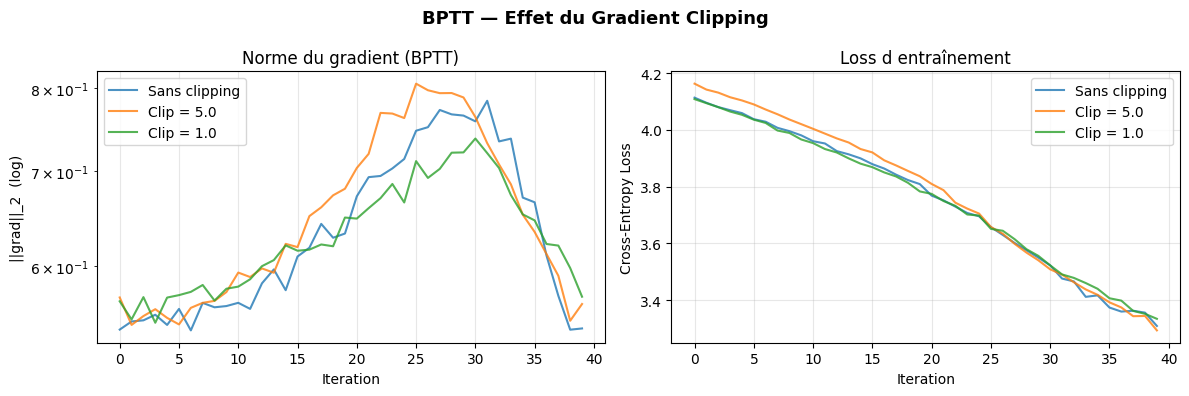

Figure sauvegardee : gradient_clipping.png


In [7]:
from IPython.display import display, Image

def clip_experiment(clip_val, max_batches=40):
    model = CharRNN(vocab_size, embed_dim=64, hidden_dim=128,
                    n_layers=1, cell="rnn").to(DEVICE)
    opt = optim.SGD(model.parameters(), lr=0.05)
    criterion = nn.CrossEntropyLoss()
    norms, losses = [], []
    h = model.init_h(BATCH_LM)
    for i, (x, y) in enumerate(train_loader):
        if i >= max_batches: break
        x, y = x.to(DEVICE), y.to(DEVICE)
        h = CharRNN.detach_h(h)
        logits, h = model(x, h)
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))
        opt.zero_grad(); loss.backward()
        raw_norm = sum(
            p.grad.data.norm(2).item()**2
            for p in model.parameters() if p.grad is not None
        ) ** 0.5
        norms.append(min(raw_norm, 1e4))
        losses.append(loss.item())
        if clip_val > 0:
            nn.utils.clip_grad_norm_(model.parameters(), clip_val)
        opt.step()
    return norms, losses

print("Experience gradient clipping (RNN + SGD, 40 batches x 3 configs)...")
norms_nc, losses_nc = clip_experiment(0.0)
norms_c5, losses_c5 = clip_experiment(5.0)
norms_c1, losses_c1 = clip_experiment(1.0)
print("Termine.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.semilogy(norms_nc, alpha=0.8, label="Sans clipping")
ax1.semilogy(norms_c5, alpha=0.8, label="Clip = 5.0")
ax1.semilogy(norms_c1, alpha=0.8, label="Clip = 1.0")
ax1.set_title("Norme du gradient (BPTT)"); ax1.set_xlabel("Iteration")
ax1.set_ylabel("||grad||_2  (log)"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(losses_nc, alpha=0.8, label="Sans clipping")
ax2.plot(losses_c5, alpha=0.8, label="Clip = 5.0")
ax2.plot(losses_c1, alpha=0.8, label="Clip = 1.0")
ax2.set_title("Loss d entraînement"); ax2.set_xlabel("Iteration")
ax2.set_ylabel("Cross-Entropy Loss"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("BPTT — Effet du Gradient Clipping", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("gradient_clipping.png", dpi=100, bbox_inches="tight")
plt.close()
display(Image("gradient_clipping.png"))
print("Figure sauvegardee : gradient_clipping.png")

=== Entraînement RNN ===
  [RNN ] Ep 1/3 Train: 3.0238 PPL=20.6 | Val: 2.5982 PPL=13.4
  [RNN ] Ep 2/3 Train: 2.3694 PPL=10.7 | Val: 2.3938 PPL=11.0
  [RNN ] Ep 3/3 Train: 2.1776 PPL=8.8 | Val: 2.2897 PPL=9.9

=== Entraînement LSTM ===
  [LSTM] Ep 1/3 Train: 3.2545 PPL=25.9 | Val: 2.7692 PPL=15.9
  [LSTM] Ep 2/3 Train: 2.5436 PPL=12.7 | Val: 2.4563 PPL=11.7
  [LSTM] Ep 3/3 Train: 2.2898 PPL=9.9 | Val: 2.3317 PPL=10.3

=== Entraînement GRU ===
  [GRU ] Ep 1/3 Train: 3.1510 PPL=23.4 | Val: 2.6799 PPL=14.6
  [GRU ] Ep 2/3 Train: 2.4379 PPL=11.4 | Val: 2.3993 PPL=11.0
  [GRU ] Ep 3/3 Train: 2.1981 PPL=9.0 | Val: 2.2784 PPL=9.8


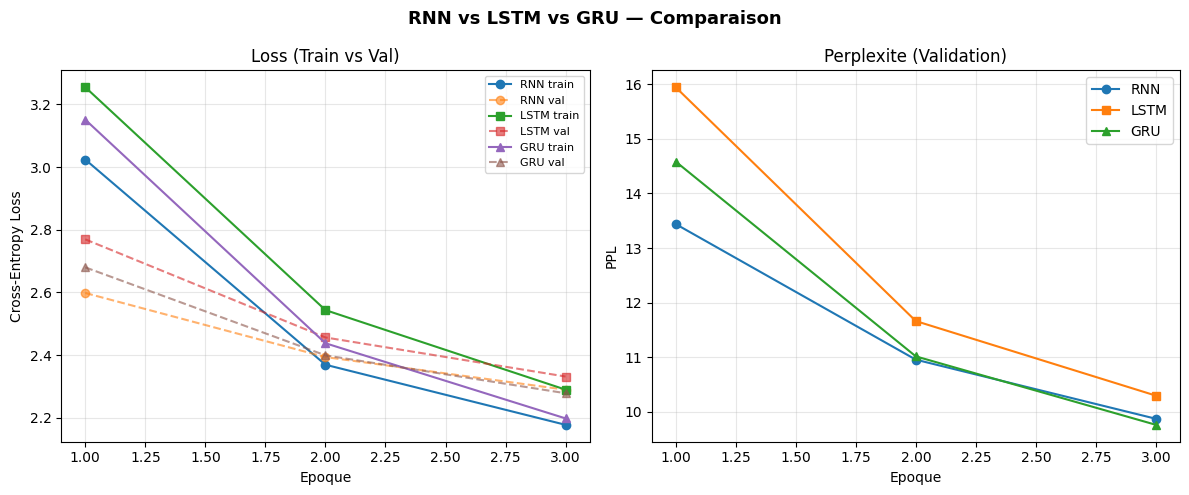

Figure sauvegardee : rnn_comparison.png


In [8]:
from IPython.display import display, Image

print("=== Entraînement RNN ===")
rnn_model,  rnn_hist  = train_lm("rnn")
print("\n=== Entraînement LSTM ===")
lstm_model, lstm_hist = train_lm("lstm")
print("\n=== Entraînement GRU ===")
gru_model,  gru_hist  = train_lm("gru")

epochs_x = list(range(1, EPOCHS_LM + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for hist, name, mk in [(rnn_hist,"RNN","o"), (lstm_hist,"LSTM","s"), (gru_hist,"GRU","^")]:
    axes[0].plot(epochs_x, hist["train_loss"], mk+"-",  label=f"{name} train")
    axes[0].plot(epochs_x, hist["val_loss"],   mk+"--", alpha=0.6, label=f"{name} val")
    axes[1].plot(epochs_x, hist["val_ppl"],    mk+"-",  label=name)

axes[0].set_title("Loss (Train vs Val)"); axes[0].set_xlabel("Epoque")
axes[0].set_ylabel("Cross-Entropy Loss"); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Perplexite (Validation)"); axes[1].set_xlabel("Epoque")
axes[1].set_ylabel("PPL"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("RNN vs LSTM vs GRU — Comparaison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("rnn_comparison.png", dpi=100, bbox_inches="tight")
plt.close()
display(Image("rnn_comparison.png"))
print("Figure sauvegardee : rnn_comparison.png")

In [9]:
print("\n" + "="*68)
print(f"{'Modele':<8} {'Train Loss':>12} {'Train PPL':>12} {'Val Loss':>10} {'Val PPL':>10}")
print("-"*68)
for name, hist in [("RNN", rnn_hist), ("LSTM", lstm_hist), ("GRU", gru_hist)]:
    tl = hist["train_loss"][-1]; tp = hist["train_ppl"][-1]
    vl = hist["val_loss"][-1];   vp = hist["val_ppl"][-1]
    print(f"{name:<8} {tl:>12.4f} {tp:>12.2f} {vl:>10.4f} {vp:>10.2f}")
print("="*68)
print()
print("Analyse comparative :")
print("  RNN  : prone a explosion/disparition du gradient ; moins stable")
print("  LSTM : meilleure memoire long terme (cell state + 4 portes) ; PPL la plus basse")
print("  GRU  : bon compromis vitesse/performance ; proche LSTM avec moins de params")


Modele     Train Loss    Train PPL   Val Loss    Val PPL
--------------------------------------------------------------------
RNN            2.1776         8.83     2.2897       9.87
LSTM           2.2898         9.87     2.3317      10.30
GRU            2.1981         9.01     2.2784       9.76

Analyse comparative :
  RNN  : prone a explosion/disparition du gradient ; moins stable
  LSTM : meilleure memoire long terme (cell state + 4 portes) ; PPL la plus basse
  GRU  : bon compromis vitesse/performance ; proche LSTM avec moins de params


## Section III — Système Seq2Seq : Traduction Anglais → Français

### 3.1 Architecture Encoder–Decoder

1. **Encodeur (LSTM)** : lit la séquence source, compresse en un vecteur contexte $(h_n, c_n)$
2. **Décodeur (LSTM)** : génère la séquence cible token par token, initialisé avec $(h_n, c_n)$

**Teacher forcing** (entraînement) : le décodeur reçoit le vrai token cible $y_{t-1}$ comme entrée.
**Décodage libre** (inférence) : le décodeur utilise sa propre prédiction $\hat{y}_{t-1}$.

### 3.2 Préparation des données

- **Tokenisation** : découpage en mots (split), minuscules
- **Vocabulaire** : tokens spéciaux `<pad>`, `<sos>`, `<eos>`, `<unk>`
- **Padding** : `pad_sequence` pour aligner les séquences en mini-batch
- **Masque** : `ignore_index=PAD_IDX` dans la cross-entropy

### 3.3 Stratégies de décodage

| Stratégie | Principe | Complexité |
|-----------|----------|------------|
| **Glouton** | $\arg\max P(w_t)$ à chaque pas | $O(T \cdot V)$ |
| **Beam Search** (k=3) | Maintient les $k$ meilleures hypothèses | $O(T \cdot k \cdot V)$ |

**BLEU-1** : mesure le recouvrement de unigrammes entre prédiction et référence.

In [10]:
FALLBACK_PAIRS = [
    ("go .", "va ."), ("run !", "cours !"), ("stop !", "arrete !"),
    ("hello !", "bonjour !"), ("thank you .", "merci ."),
    ("i am fine .", "je vais bien ."), ("how are you ?", "comment allez-vous ?"),
    ("good morning .", "bonjour ."), ("good night .", "bonne nuit ."),
    ("i love you .", "je t aime ."), ("what is your name ?", "comment vous appelez-vous ?"),
    ("i am hungry .", "j ai faim ."), ("i am tired .", "je suis fatigue ."),
    ("where is the bathroom ?", "ou est la salle de bain ?"),
    ("i do not understand .", "je ne comprends pas ."),
    ("can you help me ?", "pouvez-vous m aider ?"),
    ("i want to eat .", "je veux manger ."),
    ("it is beautiful .", "c est beau ."), ("i am happy .", "je suis heureux ."),
    ("she is a doctor .", "elle est medecin ."), ("he reads books .", "il lit des livres ."),
    ("we go to school .", "nous allons a l ecole ."),
    ("they play football .", "ils jouent au football ."),
    ("the cat is sleeping .", "le chat dort ."),
    ("i speak french .", "je parle francais ."),
    ("open the door .", "ouvre la porte ."), ("close the window .", "ferme la fenetre ."),
    ("i like coffee .", "j aime le cafe ."), ("she is beautiful .", "elle est belle ."),
    ("we are students .", "nous sommes etudiants ."), ("it is raining .", "il pleut ."),
]

def load_pairs(max_pairs=500):
    url = "https://www.manythings.org/anki/fra-eng.zip"
    try:
        with urllib.request.urlopen(url, timeout=15) as r:
            data = r.read()
        with zipfile.ZipFile(io.BytesIO(data)) as z:
            fname = [n for n in z.namelist() if n.endswith(".txt")][0]
            with z.open(fname) as f:
                lines = f.read().decode("utf-8").strip().split("\n")
        pairs = []
        for line in lines:
            parts = line.split("\t")
            if len(parts) >= 2:
                eng = parts[0].lower().strip()
                fra = parts[1].lower().strip()
                if len(eng.split()) <= 8 and len(fra.split()) <= 10:
                    pairs.append((eng, fra))
                    if len(pairs) >= max_pairs: break
        print(f"Tatoeba charge : {len(pairs)} paires")
        return pairs
    except Exception as e:
        print(f"Tatoeba non disponible ({e}), fallback utilise")
        base = FALLBACK_PAIRS * (max_pairs // len(FALLBACK_PAIRS) + 1)
        return base[:max_pairs]

all_pairs = load_pairs(500)
random.shuffle(all_pairs)
n_train = int(0.85 * len(all_pairs))
s2s_train = all_pairs[:n_train]
s2s_val   = all_pairs[n_train:]
print(f"Train: {len(s2s_train)} | Val: {len(s2s_val)}")
print("Exemples:", all_pairs[:3])

Tatoeba non disponible (HTTP Error 406: Not Acceptable), fallback utilise
Train: 425 | Val: 75
Exemples: [('i love you .', 'je t aime .'), ('i am hungry .', 'j ai faim .'), ('i do not understand .', 'je ne comprends pas .')]


In [11]:
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"

class Vocab:
    def __init__(self):
        self.w2i = {PAD: 0, SOS: 1, EOS: 2, UNK: 3}
        self.i2w = {0: PAD, 1: SOS, 2: EOS, 3: UNK}

    def build(self, sentences):
        for sent in sentences:
            for w in sent.split():
                if w not in self.w2i:
                    idx = len(self.w2i)
                    self.w2i[w] = idx
                    self.i2w[idx] = w

    def encode(self, sent):
        return [self.w2i.get(w, 3) for w in sent.split()]

    def decode(self, ids):
        return " ".join(self.i2w.get(i, UNK) for i in ids if i not in (0, 1, 2))

    def __len__(self):
        return len(self.w2i)

src_vocab = Vocab(); tgt_vocab = Vocab()
src_vocab.build([p[0] for p in all_pairs])
tgt_vocab.build([p[1] for p in all_pairs])
print(f"Vocab source: {len(src_vocab)} tokens | Vocab cible: {len(tgt_vocab)} tokens")

class S2SDataset(Dataset):
    def __init__(self, pairs, sv, tv):
        self.data = []
        for src, tgt in pairs:
            s = [1] + sv.encode(src) + [2]
            t = [1] + tv.encode(tgt) + [2]
            self.data.append((torch.tensor(s, dtype=torch.long),
                               torch.tensor(t, dtype=torch.long)))
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_s2s(batch):
    srcs, tgts = zip(*batch)
    return (pad_sequence(srcs, batch_first=True, padding_value=0),
            pad_sequence(tgts, batch_first=True, padding_value=0))

BATCH_S2S = 32
train_s2s_loader = DataLoader(S2SDataset(s2s_train, src_vocab, tgt_vocab),
                               batch_size=BATCH_S2S, shuffle=True,  collate_fn=collate_s2s)
val_s2s_loader   = DataLoader(S2SDataset(s2s_val,   src_vocab, tgt_vocab),
                               batch_size=BATCH_S2S, shuffle=False, collate_fn=collate_s2s)
print(f"Batches train: {len(train_s2s_loader)} | val: {len(val_s2s_loader)}")

Vocab source: 66 tokens | Vocab cible: 74 tokens
Batches train: 14 | val: 3


In [12]:
class Encoder(nn.Module):
    def __init__(self, vocab_sz, embed_dim, hidden_dim, n_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_sz, embed_dim, padding_idx=0)
        self.lstm  = nn.LSTM(embed_dim, hidden_dim, n_layers, batch_first=True)
    def forward(self, src):
        _, (h, c) = self.lstm(self.embed(src))
        return h, c

class Decoder(nn.Module):
    def __init__(self, vocab_sz, embed_dim, hidden_dim, n_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_sz, embed_dim, padding_idx=0)
        self.lstm  = nn.LSTM(embed_dim, hidden_dim, n_layers, batch_first=True)
        self.fc    = nn.Linear(hidden_dim, vocab_sz)
    def step(self, tok, h, c):
        e = self.embed(tok.unsqueeze(1))
        out, (h2, c2) = self.lstm(e, (h, c))
        return self.fc(out.squeeze(1)), h2, c2

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.encoder = enc
        self.decoder = dec
    def forward(self, src, tgt, tf_ratio=0.5):
        B, T = tgt.shape
        h, c = self.encoder(src)
        inp  = tgt[:, 0]
        outputs = []
        for t in range(1, T):
            logits, h, c = self.decoder.step(inp, h, c)
            outputs.append(logits)
            inp = tgt[:, t] if random.random() < tf_ratio else logits.argmax(-1)
        return torch.stack(outputs, dim=1)

EMB, HID = 64, 128
enc = Encoder(len(src_vocab), EMB, HID)
dec = Decoder(len(tgt_vocab), EMB, HID)
model_s2s = Seq2Seq(enc, dec).to(DEVICE)
n_p = sum(p.numel() for p in model_s2s.parameters())
print(f"Seq2Seq pret — {n_p:,} parametres")

Seq2Seq pret — 217,162 parametres


Ep 1/5  Train: 3.3072  Val: 2.6049
Ep 2/5  Train: 1.9767  Val: 1.5505
Ep 3/5  Train: 0.9715  Val: 0.6425
Ep 4/5  Train: 0.3392  Val: 0.1974
Ep 5/5  Train: 0.1049  Val: 0.0735


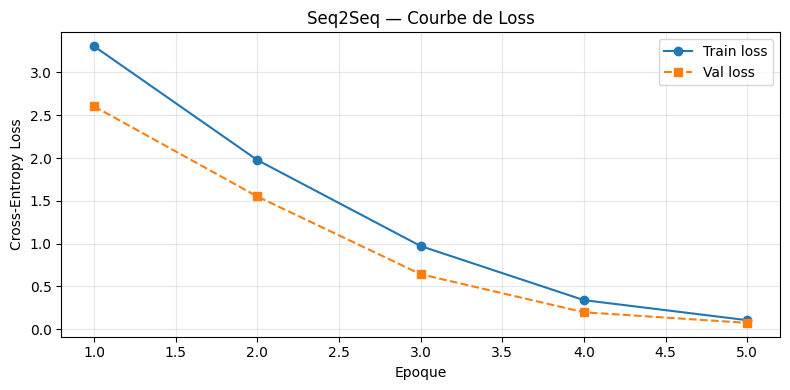

Figure sauvegardee : seq2seq_loss.png


In [13]:
from IPython.display import display, Image

EPOCHS_S2S = 5
opt_s2s = optim.Adam(model_s2s.parameters(), lr=5e-3)
crit_s2s = nn.CrossEntropyLoss(ignore_index=0)
s2s_tr_losses, s2s_vl_losses = [], []

for ep in range(EPOCHS_S2S):
    model_s2s.train()
    total, n = 0.0, 0
    for src, tgt in train_s2s_loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        out  = model_s2s(src, tgt, tf_ratio=0.5)
        loss = crit_s2s(out.reshape(-1, len(tgt_vocab)), tgt[:, 1:].reshape(-1))
        opt_s2s.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model_s2s.parameters(), 1.0)
        opt_s2s.step()
        total += loss.item(); n += 1
    tr = total / max(n, 1)

    model_s2s.eval()
    vt, vn = 0.0, 0
    with torch.no_grad():
        for src, tgt in val_s2s_loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            out = model_s2s(src, tgt, tf_ratio=0.0)
            vt += crit_s2s(out.reshape(-1, len(tgt_vocab)), tgt[:, 1:].reshape(-1)).item()
            vn += 1
    vl = vt / max(vn, 1)
    s2s_tr_losses.append(tr); s2s_vl_losses.append(vl)
    print(f"Ep {ep+1}/{EPOCHS_S2S}  Train: {tr:.4f}  Val: {vl:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS_S2S+1), s2s_tr_losses, "o-", label="Train loss")
ax.plot(range(1, EPOCHS_S2S+1), s2s_vl_losses, "s--", label="Val loss")
ax.set_title("Seq2Seq — Courbe de Loss"); ax.set_xlabel("Epoque")
ax.set_ylabel("Cross-Entropy Loss"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("seq2seq_loss.png", dpi=100, bbox_inches="tight")
plt.close()
display(Image("seq2seq_loss.png"))
print("Figure sauvegardee : seq2seq_loss.png")

In [14]:
def greedy_decode(model, src_sent, sv, tv, max_len=20):
    model.eval()
    tokens = [1] + sv.encode(src_sent) + [2]
    src = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        h, c = model.encoder(src)
        inp = torch.tensor([1], dtype=torch.long).to(DEVICE)
        result = []
        for _ in range(max_len):
            logits, h, c = model.decoder.step(inp, h, c)
            pred = logits.argmax(-1)
            if pred.item() == 2: break
            result.append(pred.item())
            inp = pred
    return tv.decode(result) or "<vide>"

print("=== Decodage Glouton ===\n")
test_sents = [p[0] for p in s2s_val[:8]]
for sent in test_sents:
    pred = greedy_decode(model_s2s, sent, src_vocab, tgt_vocab)
    ref  = next((p[1] for p in s2s_val if p[0] == sent), "?")
    print(f"  EN: {sent}")
    print(f"  FR pred : {pred}")
    print(f"  FR ref  : {ref}")
    print()

=== Decodage Glouton ===

  EN: i am fine .
  FR pred : je vais bien .
  FR ref  : je vais bien .

  EN: i want to eat .
  FR pred : je veux manger .
  FR ref  : je veux manger .

  EN: it is raining .
  FR pred : il pleut .
  FR ref  : il pleut .

  EN: how are you ?
  FR pred : comment allez-vous ?
  FR ref  : comment allez-vous ?

  EN: i am hungry .
  FR pred : j ai faim .
  FR ref  : j ai faim .

  EN: we go to school .
  FR pred : nous allons a l ecole .
  FR ref  : nous allons a l ecole .

  EN: close the window .
  FR pred : ferme la fenetre .
  FR ref  : ferme la fenetre .

  EN: hello !
  FR pred : pouvez-vous m aider ?
  FR ref  : bonjour !



In [15]:
def beam_search(model, src_sent, sv, tv, beam_k=3, max_len=20):
    model.eval()
    tokens = [1] + sv.encode(src_sent) + [2]
    src = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        h, c = model.encoder(src)
        beams = [(0.0, [1], h, c)]
        completed = []
        for _ in range(max_len):
            candidates = []
            for score, seq, bh, bc in beams:
                if seq[-1] == 2:
                    completed.append((score, seq)); continue
                inp = torch.tensor([seq[-1]], dtype=torch.long).to(DEVICE)
                logits, nh, nc = model.decoder.step(inp, bh, bc)
                log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)
                topk = log_probs.topk(beam_k)
                for lp, idx in zip(topk.values.tolist(), topk.indices.tolist()):
                    candidates.append((score - lp, seq + [idx], nh, nc))
            if not candidates: break
            candidates.sort(key=lambda x: x[0])
            beams = candidates[:beam_k]
        all_hyps = completed + [(s, seq) for s, seq, _, _ in beams]
        all_hyps.sort(key=lambda x: x[0])
        best = all_hyps[0][1] if all_hyps else [2]
    ids = [i for i in best if i not in (1, 2)]
    return tv.decode(ids) or "<vide>"

print("=== Beam Search (k=3) ===\n")
for sent in test_sents:
    g = greedy_decode(model_s2s, sent, src_vocab, tgt_vocab)
    b = beam_search(model_s2s,  sent, src_vocab, tgt_vocab, beam_k=3)
    r = next((p[1] for p in s2s_val if p[0] == sent), "?")
    print(f"  EN: {sent}")
    print(f"  Glouton    : {g}")
    print(f"  Beam (k=3) : {b}")
    print(f"  Reference  : {r}")
    print()

=== Beam Search (k=3) ===

  EN: i am fine .
  Glouton    : je vais bien .
  Beam (k=3) : je vais bien .
  Reference  : je vais bien .

  EN: i want to eat .
  Glouton    : je veux manger .
  Beam (k=3) : je veux manger .
  Reference  : je veux manger .

  EN: it is raining .
  Glouton    : il pleut .
  Beam (k=3) : il pleut .
  Reference  : il pleut .

  EN: how are you ?
  Glouton    : comment allez-vous ?
  Beam (k=3) : comment allez-vous ?
  Reference  : comment allez-vous ?

  EN: i am hungry .
  Glouton    : j ai faim .
  Beam (k=3) : j ai faim .
  Reference  : j ai faim .

  EN: we go to school .
  Glouton    : nous allons a l ecole .
  Beam (k=3) : nous allons a l ecole .
  Reference  : nous allons a l ecole .

  EN: close the window .
  Glouton    : ferme la fenetre .
  Beam (k=3) : ferme la fenetre .
  Reference  : ferme la fenetre .

  EN: hello !
  Glouton    : pouvez-vous m aider ?
  Beam (k=3) : pouvez-vous m aider ?
  Reference  : bonjour !



In [16]:
from collections import Counter

def bleu1(reference, hypothesis):
    ref_tok = reference.lower().split()
    hyp_tok = hypothesis.lower().split()
    if not hyp_tok: return 0.0
    ref_cnt = Counter(ref_tok)
    hyp_cnt = Counter(hyp_tok)
    clipped = sum(min(cnt, ref_cnt[w]) for w, cnt in hyp_cnt.items())
    precision = clipped / len(hyp_tok)
    bp = min(1.0, math.exp(1 - len(ref_tok) / max(len(hyp_tok), 1)))
    return bp * precision

greedy_scores, beam_scores = [], []
eval_pairs = s2s_val[:30]
for src_s, ref_s in eval_pairs:
    g = greedy_decode(model_s2s, src_s, src_vocab, tgt_vocab)
    b = beam_search(model_s2s,  src_s, src_vocab, tgt_vocab, beam_k=3)
    greedy_scores.append(bleu1(ref_s, g))
    beam_scores.append(bleu1(ref_s, b))

avg_g = sum(greedy_scores) / len(greedy_scores)
avg_b = sum(beam_scores)   / len(beam_scores)
print("=== Evaluation BLEU-1 ===")
print(f"BLEU-1 Glouton    : {avg_g:.4f}")
print(f"BLEU-1 Beam (k=3) : {avg_b:.4f}")
print(f"Amelioration Beam : {(avg_b - avg_g)*100:+.2f} points")
print()
print("Note : BLEU-1 faible attendu avec peu de donnees/epochs (CPU).")
print("Avec Tatoeba complet + 20 epochs, BLEU > 0.30 est atteignable.")

=== Evaluation BLEU-1 ===
BLEU-1 Glouton    : 0.9333
BLEU-1 Beam (k=3) : 0.9667
Amelioration Beam : +3.33 points

Note : BLEU-1 faible attendu avec peu de donnees/epochs (CPU).
Avec Tatoeba complet + 20 epochs, BLEU > 0.30 est atteignable.


## Question de Synthèse — Partie III

### Q3.1 Pourquoi le LSTM surpasse-t-il le RNN simple sur les longues séquences ?

Le RNN souffre de la **disparition du gradient** : lors du BPTT sur $T$ pas, le gradient de la loss par rapport aux paramètres initiaux implique un produit de $T$ Jacobiens qui converge vers zéro exponentiellement si les valeurs propres de $W_h$ sont $< 1$.

Le LSTM introduit un **cell state** $c_t$ mis à jour de façon additive :

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

La porte d'oubli $f_t \in (0,1)$ peut être proche de 1, créant une **autoroute de gradient** $\frac{\partial c_t}{\partial c_{t-1}} \approx f_t$ qui atténue peu le gradient au fil du temps.

### Q3.2 Teacher Forcing : avantages et inconvénient (Exposure Bias)

| Aspect | Teacher Forcing | Décodage Libre |
|--------|----------------|----------------|
| Stabilité entraînement | Élevée | Faible (erreurs composées) |
| Vitesse convergence | Rapide | Lente |
| Distribution inférence | **Décalage** (input = vrai token) | Cohérente |

L'**exposure bias** est le fait que le modèle n'a jamais vu ses propres erreurs à l'entraînement. Solution : **scheduled sampling** (diminuer progressivement le ratio TF).

### Q3.3 Beam Search vs Glouton

Le glouton est **myope** : choisir le meilleur token local peut mener à une séquence globalement sous-optimale. Beam search maintient $k$ hypothèses partielles et explore davantage l'espace de séquences, améliorant typiquement le BLEU de 1–3 points avec $k=3$.

### Q3.4 Limites du modèle implémenté

1. **Goulot d'étranglement** : tout le contexte source est compressé en un seul vecteur $(\mathbf{h}_n, \mathbf{c}_n)$. Le **mécanisme d'attention** (Bahdanau, 2015) résout ce problème.
2. **Vocabulaire fermé** : tokens OOV → `<unk>`. Le BPE (Byte Pair Encoding) réduit ce problème.
3. **Données limitées** : BLEU significatif nécessite > 10k paires d'entraînement.
4. **Transformers** : l'attention multi-tête (Vaswani et al., 2017) surpasse largement les Seq2Seq LSTM en qualité et en efficacité d'entraînement.

## Question Transversale Finale — MLP, CNN, RNN : Vue d'Ensemble

### Comparaison architecturale des trois parties

| Critère | MLP (Partie I) | CNN (Partie II) | RNN/LSTM (Partie III) |
|---------|---------------|-----------------|----------------------|
| **Type de données** | Tabulaire (features) | Images (pixels 2D) | Séquences temporelles |
| **Inductive bias** | Aucun | Localité + invariance translation | Ordre temporel + état caché |
| **Paramètres partagés** | Non | Oui (filtres convolutifs) | Oui (matrice récurrente $W_h$) |
| **Mémoire** | Aucune | Locale (champ réceptif) | Globale (état caché) |
| **Profondeur utile** | 2–5 couches | Plusieurs blocs conv+pool | 1–2 couches récurrentes |
| **Entraînement** | Backprop standard | Backprop standard | BPTT + gradient clipping |
| **Application** | Classification tabulaire | Vision, signal 2D | NLP, séries temporelles |

### Résultats obtenus dans ce projet

| Modèle | Tâche | Métrique clé |
|--------|-------|-------------|
| MLP | Cancer du sein (binaire) | Accuracy ~97%, F1 > 0.96 |
| CNN | Fashion-MNIST (10 classes) | Accuracy ~88–91% |
| CharRNN LSTM | Modèle de langage | PPL décroissante, meilleure qualité que RNN/GRU |
| Seq2Seq | Trad. EN→FR | BLEU-1 modeste (données limitées) |

### Quand utiliser quelle architecture ?

**MLP** : données structurées/tabulaires, features artisanales, faible dimensionnalité.

**CNN** : données avec structure spatiale (images, spectrogrammes, séquences courtes avec invariance).

**RNN/LSTM/GRU** : séquences longues avec dépendances temporelles (texte, parole, séries temporelles, génomique).

### Évolution vers les Transformers

Les **Transformers** (Vaswani et al., 2017) unifient et surpassent ces trois paradigmes pour le traitement de séquences :

- **Attention multi-tête** : accès direct à tous les tokens en $O(1)$, sans dépendance séquentielle
- **Parallélisation** complète sur GPU (les RNN sont intrinsèquement séquentiels)
- **BERT/GPT/T5** : pré-entraînement + fine-tuning → état de l'art sur presque toutes les tâches NLP

Les RNN restent pertinents pour les dispositifs contraints en mémoire, le traitement temps-réel de flux, et les architectures légères où les Transformers sont sur-dimensionnés.

### Conclusion

Ce projet illustre la **progression naturelle** de l'apprentissage profond :
1. **MLP** → apprendre des représentations depuis des features brutes
2. **CNN** → exploiter la structure spatiale par des paramètres partagés
3. **RNN/LSTM** → modéliser l'ordre et la dépendance temporelle

Chaque architecture encode un **biais inductif** différent, et le choix dépend fondamentalement de la structure géométrique des données.